## **Step 1: Mount Google Drive**

In [1]:
# from google.colab import drive

# drive.mount('/content/drive')

## **Step 2: Set Dataset Path**

In [2]:
# dataset_path = "/content/drive/MyDrive/Uni Life/Junior/3rd Term/Deep Learning/Project/Dataset"

dataset_path = "/Users/leonmarco/Downloads/Dataset"

## **Step 3: Import Libraries**

In [3]:
%pip install tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter

## **Step 4: Prepare Image Dataset**

In [5]:
def random_blur(image):
    if np.random.random() < 0.3:            # 30% chance
        sigma = np.random.uniform(0.5, 1.0) # mild blur
        image = gaussian_filter(image, sigma=(sigma, sigma, 0))
    return image

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Color Jitter
    brightness_range=[0.8, 1.2],   # ±20% brightness
    channel_shift_range=30.0,      # subtle color/saturation shift

    # Horizontal Flip 
    horizontal_flip=True,          # 50% probability (default)

    # Mild Rotation
    rotation_range=10,             # max ±10° for natural head tilts

    # Mild Blur via custom function-
    preprocessing_function=random_blur,

    # Safety: explicit fill for rotation gaps
    fill_mode='nearest',
)

# VALIDATION generator — NO augmentations, only rescaling
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)


## **Step 5: Load Training Dataset**

In [6]:
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)

Found 296 images belonging to 3 classes.


## **Step 6: Load Validation Dataset**

In [7]:
validation_data = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)

Found 74 images belonging to 3 classes.


## **Step 7: Build Simple CNN**

In [8]:
model = models.Sequential()

model.add(layers. Conv2D(32, (3,3),
                         activation="relu",
                         input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3),
                        activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))

model.add(layers.Dense(train_data.num_classes, 
                       activation="softmax"))

/opt/miniconda3/envs/ccmaclrl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Step 8: Compile Model**

In [9]:
model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 9: Train Model**

In [10]:
history = model.fit(
    train_data,
    epochs=12,
    validation_data=validation_data
)

Epoch 1/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3784 - loss: 2.0847 - val_accuracy: 0.6486 - val_loss: 1.0075
Epoch 2/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6554 - loss: 0.8439 - val_accuracy: 0.6622 - val_loss: 0.7546
Epoch 3/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6858 - loss: 0.6284 - val_accuracy: 0.6757 - val_loss: 0.6289
Epoch 4/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7736 - loss: 0.4777 - val_accuracy: 0.5405 - val_loss: 0.6842
Epoch 5/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.7230 - loss: 0.5002 - val_accuracy: 0.7027 - val_loss: 0.7082
Epoch 6/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7872 - loss: 0.4354 - val_accuracy: 0.6351 - val_loss: 0.6074
Epoch 7/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.7838 - loss: 0.4354 - val_accuracy: 0.6622 - val_loss: 0.5989
Epoch 8/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8041 - loss: 0.4144 - val_accuracy: 0.6351 - val_loss:

## **Step 10: Evaluate Model**

In [11]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy: ", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5946 - loss: 0.7530 
Validation Accuracy:  0.5945945978164673


## **Step 11: Plot Accuracy & Loss**

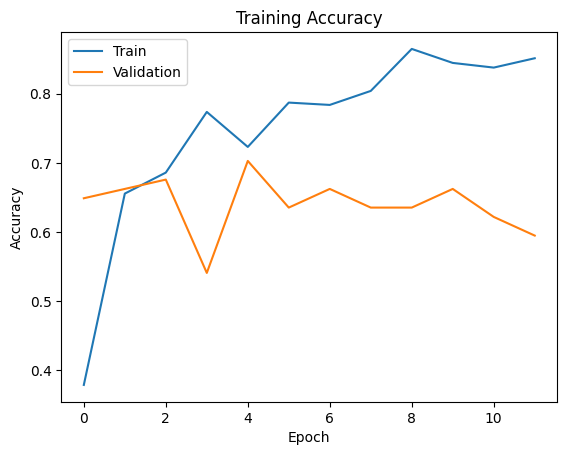

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

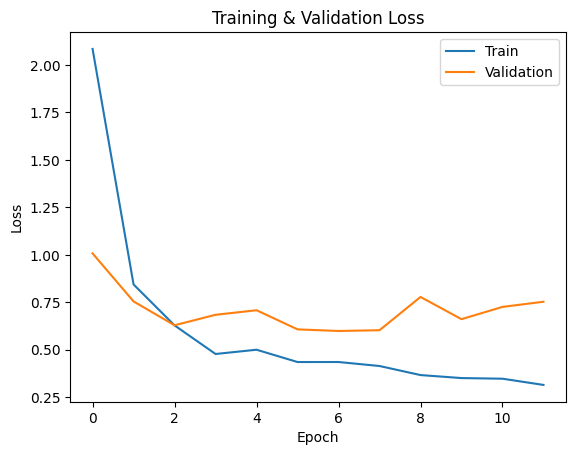

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## **Step 12: Confusion Matrix**

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step 


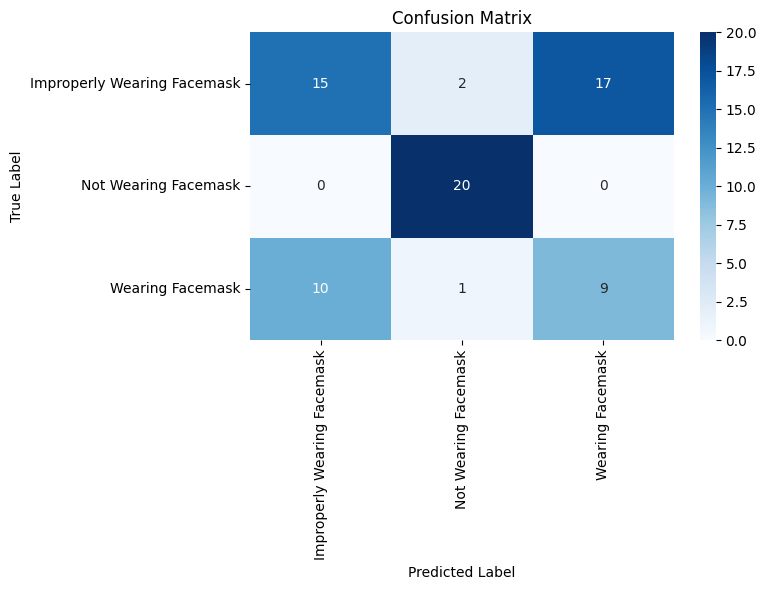


Classification Report:

                             precision    recall  f1-score   support

Improperly Wearing Facemask       0.60      0.44      0.51        34
       Not Wearing Facemask       0.87      1.00      0.93        20
           Wearing Facemask       0.35      0.45      0.39        20

                   accuracy                           0.59        74
                  macro avg       0.61      0.63      0.61        74
               weighted avg       0.60      0.59      0.59        74



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

validation_data.reset()  # Reset generator to start from beginning
y_pred_probs = model.predict(validation_data, steps=len(validation_data))
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_data.classes

# Get class names (e.g., Masked, Unmasked, Improperly Worn)
class_names = list(train_data.class_indices.keys())

# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Print detailed classification report (precision, recall, f1-score)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


## **Step 13: Save the model**

In [ ]:
# # Save the trained model 
# model.save('mask_model.h5')

# # Print the class labels to ensure they match the list in app.py
# print("Class Indices:", train_data.class_indices)

Class Indices: {'Improperly Wearing Facemask': 0, 'Not Wearing Facemask': 1, 'Wearing Facemask': 2}


## **Test**

In [16]:
# import tkinter as tk
# from tkinter import filedialog
# from tensorflow.keras.preprocessing import image
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. Create a local file browser popup
# root = tk.Tk()
# root.withdraw() # Hides the background main window
# root.call('wm', 'attributes', '.', '-topmost', True) # Forces the popup to the front

# print("Please select an image in the popup window...")
# # Opens the file explorer and saves the path of the file you click
# filename = filedialog.askopenfilename(title="Select an image to test")

# if not filename:
#     print("Upload canceled. Please run the cell again to select a file.")
# else:
#     print(f"Successfully loaded: {filename}")
    
#     # 2. Load the image and resize to the same size used in training
#     img = image.load_img(filename, target_size=(128,128))
     
#     # 3. Convert image to numpy array
#     img_array = image.img_to_array(img)
     
#     # 4. Normalize pixel values (same preprocessing used during training)
#     img_array = img_array / 255.0
     
#     # 5. Expand dimensions so the model receives a batch
#     img_array = np.expand_dims(img_array, axis=0)
     
#     # 6. Predict class
#     prediction = model.predict(img_array)
     
#     # 7. Get predicted class index
#     predicted_class = np.argmax(prediction)
     
#     # 8. Retrieve class labels from training dataset
#     # (Requires train_data to be loaded in memory)
#     class_labels = list(train_data.class_indices.keys())
     
#     # 9. Display the image
#     plt.imshow(img)
#     plt.axis('off')
     
#     # 10. Display predicted label
#     print("Predicted Class:", class_labels[predicted_class])
#     plt.title("Prediction: " + class_labels[predicted_class])
#     plt.show()

# --------------------------------------------------------------------------------------------------------------------------------------------------------

# from google.colab import files
# from tensorflow.keras.preprocessing import image
# import numpy as np
# import matplotlib.pyplot as plt

# # Upload an image file
# uploaded = files.upload()
 
# # Get uploaded file name
# filename = list(uploaded.keys())[0]
 
# # Load the image and resize to the same size used in training
# img = image.load_img(filename, target_size=(128,128))
 
# # Convert image to numpy array
# img_array = image.img_to_array(img)
 
# # Normalize pixel values (same preprocessing used during training)
# img_array = img_array / 255.0
 
# # Expand dimensions so the model receives a batch
# img_array = np.expand_dims(img_array, axis=0)
 
# # Predict class
# prediction = model.predict(img_array)
 
# # Get predicted class index
# predicted_class = np.argmax(prediction)
 
# # Retrieve class labels from training dataset
# class_labels = list(train_data.class_indices.keys())
 
# # Display the image
# plt.imshow(img)
# plt.axis('off')
 
# # Display predicted label
# print("Predicted Class:", class_labels[predicted_class])
 
# # Show image with title
# plt.title("Prediction: " + class_labels[predicted_class])
# plt.show()